In [10]:
import numpy as np
from numba import njit
import matplotlib.pyplot as plt

from multi_mems import *

ver()

This is multi_mems version 1.7


Unfortunately, it is not possible yet to use one simulation code for arbitrary dimensions (gle_nd_sim.py), since sclicing the force_matrix with tuples does not work in numba. Hence, we use individual codes for 1D, 2D or 3D simulations, which can be easily modified for higher dimensions.

### Prepare the 2D Potential Landscape for the Simulation
We create a 2D force matrix, which we will insert into the simulation script

In [11]:
xmin,xmax = -180,180
n_dim = 2
bins1 = np.linspace(xmin,xmax,200)
bins2 = np.linspace(xmin,xmax,200)


fe_2d =  np.loadtxt('fe_pentane.txt', delimiter = ',')
pos_2d = np.zeros((len(bins1)-1,n_dim))

pos_2d.T[0] +=(bins1[1:]+bins1[:-1])/2
pos_2d.T[1] +=(bins2[1:]+bins2[:-1])/2

pos_ana,fe_ana,du_func, pos_fine,force_matrix  = get_du_nd(pos_2d,fe_2d,n_dim = n_dim,degrees=3)

print(pos_fine.shape,force_matrix.shape)


(2, 199) (2, 199, 199)


### Set the Parameters (Dummy Values)

In [15]:
nsteps=int(2e7)

kT=2.494
dt=2e-3
trunc = 100*dt/0.002
n_dim=2
uncorr_fr = False
kT = 2.494

gamma = 4e-3 #4e-4
gammas = np.array([[gamma,-gamma/10],[-gamma/10,gamma]])
tau = 1
taus = np.array([[tau,-tau/100],[-tau/100,tau]])
ks = np.dot(gammas,np.linalg.inv(taus))

gammas = gammas.reshape(1,n_dim,n_dim) #shape required, increase the first dimensional for a multi-exponential simulation
taus = taus.reshape(1,n_dim,n_dim)
ks = ks.reshape(1,n_dim,n_dim)
n_exp = len(gammas)
print(n_exp)

m = 3e-5
mass = np.array([[m,-m/20],[-m/20,m]])


1


### Run the Simulation

In [16]:
#generate initial condition
v0 = np.zeros([n_dim,])
y0 = np.zeros([n_exp,n_dim,])
x0 = np.zeros([n_dim,])
x0[0] = 0
x0[1] = 0
v0[0]=random.gauss(0.0,math.sqrt(kT/mass[0][0]))
v0[1]=random.gauss(0.0,math.sqrt(kT/mass[1][1]))

for j in range(n_exp):
    y0[j][0]=random.gauss(x0[0],math.sqrt(kT*np.absolute(np.dot(np.linalg.inv(gammas[j]),taus[j]))[0][0]))
    y0[j][1]=random.gauss(x0[1],math.sqrt(kT*np.absolute(np.dot(np.linalg.inv(gammas[j]),taus[j]))[1][1]))

#perform the RK4 simulation
x,vv,yy = integrate_gle_2_dim_exp(x0,v0, y0,ks, gammas, 
                                      mass,nsteps, dt, kT,force_matrix = force_matrix,
                                      force_bins = pos_fine,uncorr_fr = uncorr_fr)

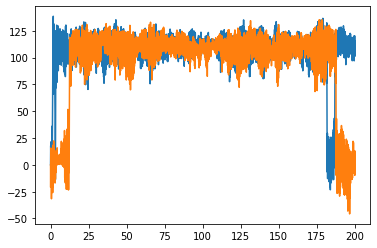

In [17]:
t = np.arange(0,len(x)*dt,dt)
plt.plot(t[:100000],x.T[0][:100000])
plt.plot(t[:100000],x.T[1][:100000])

### Check the Simulation by the Computation of the Potential of Mean Force

#### 1D Landscape

<ipython-input-18-1c4ce89d3613>:4: RuntimeWarning: divide by zero encountered in log
  fe_sim_1d = -np.log(hist_1d)*kT


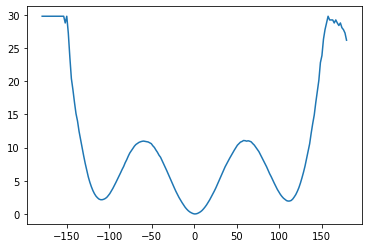

In [18]:
hist,edges=np.histogram(x.T[0], bins=bins1, density=True)
pos_1d =(edges[1:]+edges[:-1])/2
hist_1d = hist
fe_sim_1d = -np.log(hist_1d)*kT
fe_sim_1d[np.where(fe_sim_1d == np.inf)] = np.nanmax(fe_sim_1d[fe_sim_1d != np.inf])
fe_sim_1d -=np.min(fe_sim_1d)

plt.plot(pos_1d,fe_sim_1d)

#### 2D Landscape

simulated


<ipython-input-19-125d7d40a628>:8: RuntimeWarning: divide by zero encountered in log
  fe_sim_2d = -np.log(hist_2d)*kT


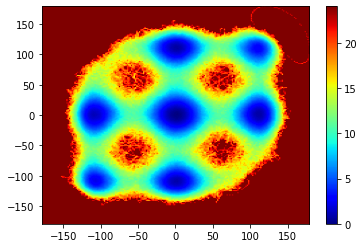

reference


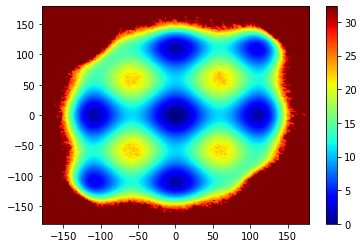

difference


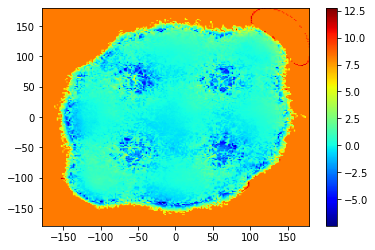

In [19]:
hist=np.histogramdd(np.stack([x.T[0],x.T[1]], axis=1), bins=(bins1,bins2), density=True)

pos_2d_sim = np.zeros((len(bins1)-1,2))
    
for z in range(n_dim):
        pos_2d_sim.T[z] +=(hist[1][z][1:]+hist[1][z][:-1])/2
hist_2d = hist[0] 
fe_sim_2d = -np.log(hist_2d)*kT
fe_sim_2d[np.where(fe_sim_2d == np.inf)] = np.nanmax(fe_sim_2d[fe_sim_2d != np.inf])

fe_sim_2d -=np.min(fe_sim_2d)

print('simulated')
plt.imshow((fe_sim_2d.T), aspect='auto',origin = 'lower',
           cmap=plt.cm.jet, extent = [np.min(pos_2d.T[0]) , np.max(pos_2d.T[0]), np.min(pos_2d.T[1]) , np.max(pos_2d.T[1])])
plt.colorbar()
plt.show()

print('reference')
plt.imshow((fe_2d.T), aspect='auto',origin = 'lower',
           cmap=plt.cm.jet, extent = [np.min(pos_2d.T[0]) , np.max(pos_2d.T[0]), np.min(pos_2d.T[1]) , np.max(pos_2d.T[1])])
plt.colorbar()
plt.show()

print('difference')
plt.imshow((fe_2d.T-fe_sim_2d.T), aspect='auto',origin = 'lower',
           cmap=plt.cm.jet, extent = [np.min(pos_2d.T[0]) , np.max(pos_2d.T[0]), np.min(pos_2d.T[1]) , np.max(pos_2d.T[1])])
plt.colorbar()
plt.show()


### Extract the 2D Kernel (Note that they won't fit the analytical ones perfectly since the simulation length may be too short)

In [20]:
xvaf1=xvframe(x.T[0],np.gradient(x.T[0],dt),t,fix_time=True)
xvaf2=xvframe(x.T[1],np.gradient(x.T[1],dt),t,fix_time=True)
#create concatenated dataframe
xvaf = xvaf1.join(xvaf2, how='outer', lsuffix='_1', rsuffix='_2')
xvaf.head()

,t_1,x_1,v_1,t_2,x_2,v_2
#t,,,,,,
0.000,0.000,0.000000,140.573259,0.000,0.000000,-487.834893
0.002,0.002,0.281147,144.944800,0.002,-0.975670,-487.430085
0.004,0.004,0.579779,153.310289,0.004,-1.949720,-486.064508
0.006,0.006,0.894388,161.031834,0.006,-2.919928,-483.748392
0.008,0.008,1.223907,168.530079,0.008,-3.884714,-480.286588


In [21]:
mm = multi_dim_gle(trunc = 10, bins = 200, kT =2.494, free_energy = 'MV',physical = True,diagonal_mass = False,plot=False)

t_corr, v_corr_matrix,xU_corr_matrix,force_funcs = mm.compute_correlations_G(xvaf)
#you can use the multiprocessing argument to accelerate the extraction
t_kernel, ikernel_matrix, kernel_matrix= mm.compute_kernel_mat_G(v_corr_matrix,xU_corr_matrix,
                                                          first_kind = True, d  = 0,
                                                          multiprocessing=5)

dimension of system: 2
found dt = 0.002
calculate all correlation functions...
calculate multi-variate free energy landscape


/home/hendrykn123/.local/lib/python3.9/site-packages/multi_mems/multi_dim_gle.py:461: RuntimeWarning: divide by zero encountered in log
  fe=-np.log(hist) #in units of kT!


used kT
2.494
constant mass matrix:
[[ 2.96810053e-05 -1.49972279e-06]
 [-1.49972279e-06  2.99879366e-05]]


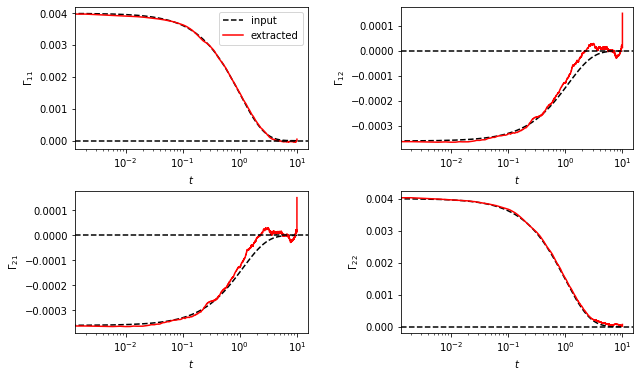

In [22]:
def eigy_expm(A):
    vals,vects = np.linalg.eig(A)
    return np.einsum('...ik, ...k, ...kj -> ...ij',
                     vects,np.exp(vals),np.linalg.inv(vects))

def func_exp(t,gammas,taus):
    
    ks = np.dot(gammas,np.linalg.inv(taus))
    
    A = np.zeros([len(t),2,2])
    for i in range(len(t)):
        A[i] = -t[i]*np.linalg.inv(taus)

    expA = eigy_expm(A)
    func_ana  = np.einsum('jk,ikl -> ijl',ks,expA)
    
    return np.real(func_ana)

kernel_matrix_ana = func_exp(t_kernel,gammas[0],taus[0])

#increase statistics
kernel_matrix.T[0][1] = (kernel_matrix.T[1][0]+kernel_matrix.T[0][1])/2
kernel_matrix.T[1][0] = kernel_matrix.T[0][1]

fig, ax = plt.subplots(n_dim,n_dim, figsize=(5*n_dim,3*n_dim))
plt.subplots_adjust(wspace = 0.4)
plt.subplots_adjust(hspace = 0.3)
for i in range(0,n_dim):
    for j in range(0, n_dim): 
        ax[i][j].plot(t_kernel,kernel_matrix_ana.T[j][i], color = 'k',ls='--',label='input')
        ax[i][j].plot(t_kernel,kernel_matrix.T[j][i], color = 'r',label='extracted')
        ax[i][j].set_xscale('log')
        ax[i][j].set_ylabel(r'$\Gamma_{%s%s}$' % (i+1, j+1))
        ax[i][j].set_xlabel('$t$')

        ax[i][j].axhline(y = 0, linestyle = '--', color = 'k')
ax[0][0].legend(loc='best')                    
plt.show()

### Simulation of 1D Systems (does not work with the code above, would be also slow due to unecessary matrix multiplication)
More information about 1D embedding code can be found in: https://github.com/hkiefer/gle_sims

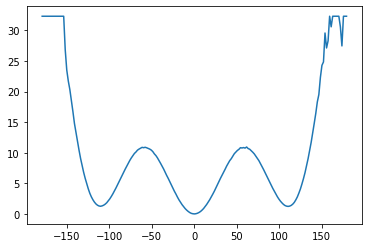

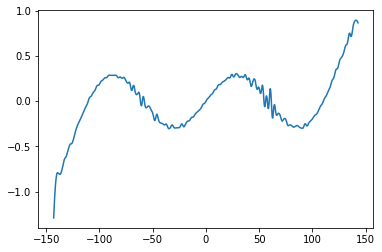

In [ ]:
def polynom(x,a,b):
    b = -np.abs(b)
    return(a*x+b*x**2)

def polynom2(x,a,b):
    b = np.abs(b)
    return(a*x+b*x**2)

xmin,xmax = -180,180
n_dim = 1
bins1 = np.linspace(xmin,xmax,200)


fe_2d =  np.loadtxt('fe_pentane.txt', delimiter = ',')

pos_1d = np.zeros((len(bins1)-1,n_dim))
pos_1d.T[0] +=(bins1[1:]+bins1[:-1])/2

fe_1d = fe_2d[:,99]

plt.plot(pos_1d,fe_1d)
plt.show()


#1D splining
fe_spline,force_bins,force_matrix = spline_fe_for_sim_1d(pos_1d[20:-20],fe_1d[20:-20])
plt.plot(force_bins,force_matrix)



0.004


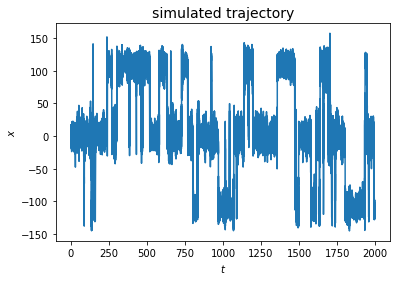

In [ ]:
nsteps=int(5e7)

kT=2.494
dt=2e-3
trunc = 100*dt/0.002

gamma = 4e-3 #4e-4
gammas = np.array([gamma])
tau = 1
taus = np.array([tau])

m = 3e-5
    
n_exp = len(gammas)
print(np.sum(gammas))

x0=0
v0=0#np.random.normal(0.0,math.sqrt(kT/m))
y0=np.zeros(n_exp)

for j in range(n_exp):
    y0[j]=np.random.normal(x0,math.sqrt(kT*np.absolute(taus[j]/gammas[j])))


x,vv,yy = integrate_gle_1d_multi_exp_arb_pot(nsteps, dt, m, gammas, taus,x0, y0, v0, kT,force_bins,force_matrix)


start = 100
end = int(len(x)*1)

x = x[start:end] #equilibrium time
t = np.arange(0,len(x)*dt,dt)


plt.plot(t[:1000000],x[:1000000])
plt.title('simulated trajectory',fontsize=14)
plt.xlabel(r'$t$')
plt.ylabel(r'$x$')
plt.show()


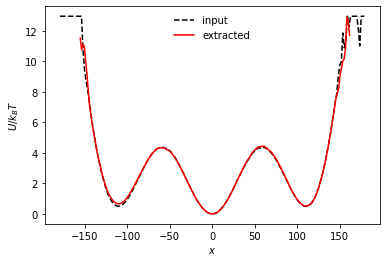

dimension of system: 1
found dt = 0.002
calculate all correlation functions...
used kT
2.494
constant mass matrix:
[[2.96510128e-05]]


In [ ]:

xvaf=xvframe(x,np.gradient(x,dt),t,fix_time=True)
xvaf.columns = ['t_1', 'x_1', 'v_1']
xvaf.head()

mm = multi_dim_gle(trunc = 10, bins = 200, kT =2.494, free_energy = 'ADD',physical = True,diagonal_mass = False,plot = False)
pos_arrays, fe_arrays = mm.compute_free_energy_landscape(xvaf)

plt.plot(pos_1d,fe_1d/kT,label='input',color='k',ls='--')
plt.plot(pos_arrays[0],fe_arrays[0],label='extracted',color='r')

plt.legend(frameon=False)
plt.ylabel(r'$U/k_BT$')
plt.xlabel(r'$x$')
plt.show()

t_corr, v_corr_matrix,xU_corr_matrix,force_funcs = mm.compute_correlations_G(xvaf)
#you can use the multiprocessing argument to accelerate the extraction
t, ikernel_matrix, kernel_matrix= mm.compute_kernel_mat_G(v_corr_matrix,xU_corr_matrix,
                                                          first_kind = True, d  = 0,multiprocessing=5)

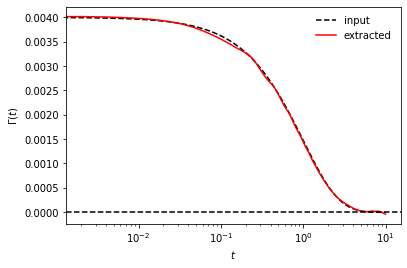

In [ ]:
plt.plot(t,gamma/tau*np.exp(-t/tau),label='input',color='k',ls='--')
plt.plot(t,kernel_matrix.T[0][0],label='extracted',color='r')

plt.xscale('log')
plt.xlabel(r'$t$')
plt.ylabel(r'$\Gamma(t)$')
plt.axhline(y = 0, linestyle = '--', color = 'k')
plt.legend(frameon=False)